In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from gwgraphs import *

In [2]:
def read_graph_data():
  # Read the adjacency matrix (edges)
  with open("IMDB-MULTI_A.txt", "r") as f:
      edges = [tuple(map(int, line.split(','))) for line in f]

  # Read graph indicators
  with open("IMDB-MULTI_graph_indicator.txt", "r") as f:
      graph_indicators = [int(line.strip()) for line in f if line.strip()]

  # Read graph labels
  with open("IMDB-MULTI_graph_labels.txt", "r") as f:
      graph_labels = [int(line.strip()) for line in f]

  return edges, graph_indicators, graph_labels


def construct_networkx_graph(edges, graph_indicators, graph_labels):
  graphs = {}
  for node_id, graph_id in enumerate(graph_indicators, start=1):
      if graph_id not in graphs:
          graphs[graph_id] = nx.Graph(label=graph_labels[graph_id - 1])

  for edge in edges:
      node1, node2 = edge
      graph_id = graph_indicators[
          node1 - 1]  # Determine which graph the edge belongs to
      graphs[graph_id].add_edge(node1, node2)

  return graphs


def compute_averages(graphs):
  # Initialize variables
  total_nodes = 0
  class_nodes = {}
  class_counts = {}
  # Iterate through graphs to compute totals
  for graph_id, graph in graphs.items():
      num_nodes = graph.number_of_nodes()
      total_nodes += num_nodes

      # Get the class label for the current graph
      graph_label = graph.graph['label']

      if graph_label not in class_nodes:
          class_nodes[graph_label] = 0
          class_counts[graph_label] = 0

      class_nodes[graph_label] += num_nodes
      class_counts[graph_label] += 1
  # Calculate total average
  total_avg = round(total_nodes / len(graphs))

  # Calculate class-based averages
  class_averages = {label: round(class_nodes[label] / count)
                    for label, count in class_counts.items()}

  return total_avg, class_averages


def compute_distance_matrix(graph):
  num_nodes = len(graph.nodes)
  distance_matrix = np.full((num_nodes, num_nodes), 10000.0)

  # Get the correct node indices to be used for indexing the matrix
  node_list = list(graph.nodes())
  node_index = {node: i for i, node in enumerate(node_list)}

  for node in graph.nodes:
      lengths = nx.shortest_path_length(graph, source=node, weight="weight")

      for target, length in lengths.items():
          if target in node_index:
              distance_matrix[node_index[node], node_index[target]] = length

  return distance_matrix


def compute_graph_stats(graphs):
  # Initialize counters
  total_edges = 0
  total_nodes = 0
  class1_edges = 0
  class1_nodes = 0
  class2_edges = 0
  class2_nodes = 0
  class3_edges = 0
  class3_nodes = 0

  # Collect degrees for plotting
  all_degrees = []
  class1_degrees = []
  class2_degrees = []
  class3_degrees = []

  for graph in graphs.values():
      num_edges = graph.number_of_edges()
      num_nodes = graph.number_of_nodes()
      degrees = [d for n, d in graph.degree()]

      total_edges += num_edges
      total_nodes += num_nodes
      all_degrees.extend(degrees)

      if graph.graph['label'] == 1:
          class1_edges += num_edges
          class1_nodes += num_nodes
          class1_degrees.extend(degrees)
      elif graph.graph['label'] == 2:
          class2_edges += num_edges
          class2_nodes += num_nodes
          class2_degrees.extend(degrees)
      elif graph.graph['label'] == 3:
          class3_edges += num_edges
          class3_nodes += num_nodes
          class3_degrees.extend(degrees)

  # Calculate statistics
  edge_density = (2 * total_edges) / (total_nodes * (total_nodes - 1))
  avg_degree = 2 * total_edges / total_nodes
  avg_degree_class1 = 2 * class1_edges / class1_nodes if class1_nodes > 0 else 0
  avg_degree_class2 = 2 * class2_edges / class2_nodes if class2_nodes > 0 else 0
  avg_degree_class3 = 2 * class3_edges / class3_nodes if class3_nodes > 0 else 0

  print(f"\nGraph Statistics:")
  print(f"Edge Density: {edge_density:.4f}")
  print(f"Average Degree (Full Dataset): {avg_degree:.2f}")
  print(f"Average Degree (Class 1): {avg_degree_class1:.2f}")
  print(f"Average Degree (Class 2): {avg_degree_class2:.2f}")
  print(f"Average Degree (Class 3): {avg_degree_class3:.2f}")

  # Plot degree distributions

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

  # Full dataset degree distribution
  ax1.hist(all_degrees, bins=30, alpha=0.7, color='blue', label='All')
  ax1.set_title('Degree Distribution (Full Dataset)')
  ax1.set_xlabel('Degree')
  ax1.set_ylabel('Frequency')
  ax1.legend()

  # Class-wise degree distribution
  bins = np.linspace(min(all_degrees), max(all_degrees), 31)
  class1_hist, _ = np.histogram(class1_degrees, bins=bins)
  class2_hist, _ = np.histogram(class2_degrees, bins=bins)
  class3_hist, _ = np.histogram(class3_degrees, bins=bins)
  bin_centers = (bins[:-1] + bins[1:]) / 2
  width = (bins[1] - bins[0]) * 0.25

  ax2.bar(bin_centers - width, class1_hist, width, color='gray', label='Class 1')
  ax2.bar(bin_centers, class2_hist, width, color='orange', label='Class 2')
  ax2.bar(bin_centers + width, class3_hist, width, color='blue', label='Class 3')
  ax2.set_title('Degree Distribution by Class')
  ax2.set_xlabel('Degree')
  ax2.set_ylabel('Frequency')
  ax2.legend()

  plt.tight_layout()
  plt.savefig('degree_distributions.png')
  plt.show()
  plt.close()

In [3]:
edges, graph_indicators, graph_labels = read_graph_data()
graphs = construct_networkx_graph(edges, graph_indicators, graph_labels)
for graph_id, graph in graphs.items():
    print(
        f"Graph ID: {graph_id}, number of nodes: {graph.number_of_nodes()}, label: {graph.graph['label']}"
        )
total_avg, class_averages = compute_averages(graphs)
print(f"Average number of nodes in entire dataset: {total_avg}")
print("Average number of nodes for each class:")
for class_label, avg_nodes in class_averages.items():
        print(f"  Class {class_label}: {avg_nodes}")

Graph ID: 1, number of nodes: 7, label: 1
Graph ID: 2, number of nodes: 13, label: 1
Graph ID: 3, number of nodes: 7, label: 1
Graph ID: 4, number of nodes: 7, label: 1
Graph ID: 5, number of nodes: 10, label: 1
Graph ID: 6, number of nodes: 8, label: 1
Graph ID: 7, number of nodes: 7, label: 1
Graph ID: 8, number of nodes: 8, label: 1
Graph ID: 9, number of nodes: 13, label: 1
Graph ID: 10, number of nodes: 22, label: 1
Graph ID: 11, number of nodes: 8, label: 1
Graph ID: 12, number of nodes: 17, label: 1
Graph ID: 13, number of nodes: 8, label: 1
Graph ID: 14, number of nodes: 22, label: 1
Graph ID: 15, number of nodes: 7, label: 1
Graph ID: 16, number of nodes: 16, label: 1
Graph ID: 17, number of nodes: 14, label: 1
Graph ID: 18, number of nodes: 7, label: 1
Graph ID: 19, number of nodes: 9, label: 1
Graph ID: 20, number of nodes: 8, label: 1
Graph ID: 21, number of nodes: 12, label: 1
Graph ID: 22, number of nodes: 24, label: 1
Graph ID: 23, number of nodes: 9, label: 1
Graph ID: 

In [4]:
graphs_list = []
labels_list = []
for graph_id, graph in graphs.items():
    # Add the graph object to the list
    graphs_list.append(graph)

    # Extract the label and add to the label list
    label = graph.graph['label']
    labels_list.append(label)

# Convert graphs into pairwise distance matrices
distance_matrices = [compute_distance_matrix(graph) for graph in graphs_list]

# Determine number of elements of each class
print("Elements of Class 1: ", labels_list.count(1))
print("Elements of Class 2: ", labels_list.count(2))
print("Elements of Class 3: ", labels_list.count(3))

Elements of Class 1:  500
Elements of Class 2:  500
Elements of Class 3:  500



Graph Statistics:
Edge Density: 0.0005
Average Degree (Full Dataset): 10.14
Average Degree (Class 1): 9.23
Average Degree (Class 2): 11.42
Average Degree (Class 3): 9.84


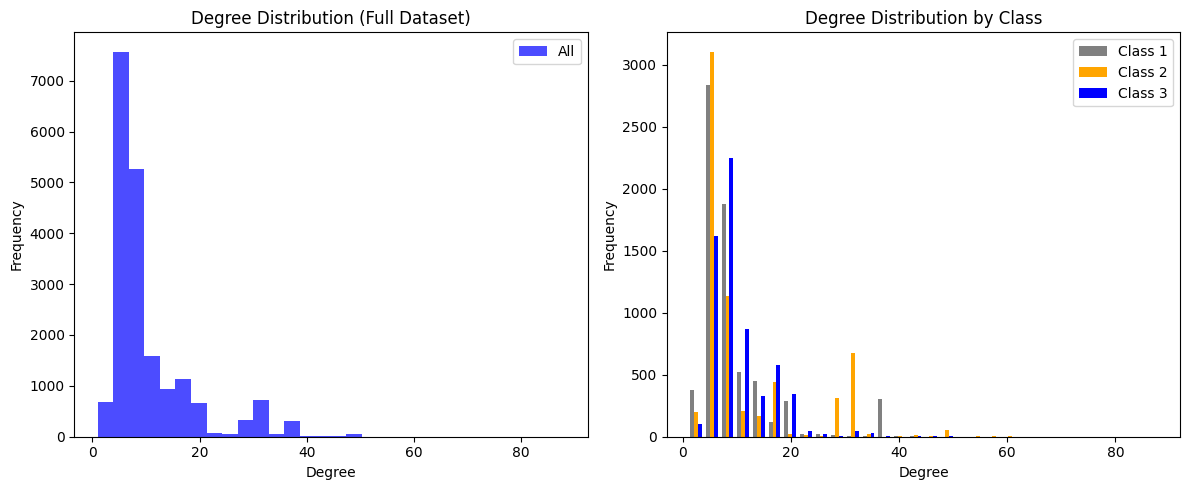

In [5]:
# Compute and display graph statistics
compute_graph_stats(graphs)

In [10]:
# ATTEMPT 1: Use the dataset's average # of nodes for the barycenters
def gw_barycenter_class_alg_multi(distance_matrices,
                                   labels,
                                   num_folds,
                                   num_nodes,
                                   method,
                                   seed=42,
                                   log=False):
    """Implements GW-NCC multi-class classification algorithm for 3 classes.
    Parameters:
    distance_matrices: list of pairwise distance matrices
    labels: list of labels for each graph
    num_folds: number of folds for cross-validation
    num_nodes: number of nodes for the GW barycenter of each class
    method: cross-validation method, either "kfold" (for k-fold CV) or "stratk" (for stratified k-fold CV)
    seed: random seed for reproducibility
    log: boolean flag to print additional information
    
    Returns:
    class_acc_list: list of classification accuracies for each fold
    class1_acc_list: list of classification accuracies for class 1 for each fold
    class2_acc_list: list of classification accuracies for class 2 for each fold
    class3_acc_list: list of classification accuracies for class 3 for each fold
    f1_score_list: list of F1 scores for each fold
    class1_barys: list of GW barycenters for class 1 for each fold
    class2_barys: list of GW barycenters for class 2 for each fold
    class3_barys: list of GW barycenters for class 3 for each fold"""
    
    class_acc_list = []  # list to store classification accuracies from each fold
    class1_acc_list = []  # list to store class 1 accuracies from each fold
    class2_acc_list = []  # list to store class 2 accuracies from each fold
    class3_acc_list = []  # list to store class 3 accuracies from each fold
    f1_score_list = []  # list to store F1 scores from each fold
    class1_barys = []  # list to store class1 barycenters from each fold
    class2_barys = []  # list to store class2 barycenters from each fold
    class3_barys = []  # list to store class3 barycenters from each fold

    assert method in ["kfold", "stratk"]
    if method == "kfold":
        k_folds = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
        print("k-fold CV selected")
    else:
        k_folds = StratifiedKFold(n_splits=num_folds,
                                  shuffle=True,
                                  random_state=seed)
        print("Stratified k-fold CV selected")
    start = time.time()
    for i, (train_index,
            test_index) in enumerate(k_folds.split(distance_matrices, labels)):
        print(f"Fold {i}:")
        if log is True:
            print(f"  Train: index={train_index}")
            print(f"  Test:  index={test_index}")
        X_train, X_test = [distance_matrices[idx] for idx in train_index
                           ], [distance_matrices[idx] for idx in test_index]
        y_train, y_test = [labels[idx] for idx in train_index
                           ], [labels[idx] for idx in test_index]
        X_train_class1 = [
            X_train[j] for j in range(len(X_train)) if y_train[j] == 1
        ]
        X_train_class2 = [
            X_train[j] for j in range(len(X_train)) if y_train[j] == 2
        ]
        X_train_class3 = [
            X_train[j] for j in range(len(X_train)) if y_train[j] == 3
        ]
        
        # Compute the GW barycenter for each category
        barycenter_matrix_class1 = ot.gromov.gromov_barycenters(
            N=num_nodes,
            Cs=X_train_class1,
            loss_fun='square_loss',
            random_state=seed)
        if log is True:
            print("GW barycenter for Class 1 graphs:",
                  barycenter_matrix_class1, f"Fold {i}")
        class1_barys.append(barycenter_matrix_class1)
        print("GW barycenter for Class 1 graphs computed")
        
        barycenter_matrix_class2 = ot.gromov.gromov_barycenters(
            N=num_nodes,
            Cs=X_train_class2,
            loss_fun='square_loss',
            random_state=seed)
        class2_barys.append(barycenter_matrix_class2)
        if log is True:
            print("GW barycenter for Class 2 graphs:",
                  barycenter_matrix_class2, f"Fold {i}")
        print("GW barycenter for Class 2 graphs computed")
        
        barycenter_matrix_class3 = ot.gromov.gromov_barycenters(
            N=num_nodes,
            Cs=X_train_class3,
            loss_fun='square_loss',
            random_state=seed)
        class3_barys.append(barycenter_matrix_class3)
        if log is True:
            print("GW barycenter for Class 3 graphs:",
                  barycenter_matrix_class3, f"Fold {i}")
        print("GW barycenter for Class 3 graphs computed")

        # Compute distances between barycenters
        gw_12, log_12 = ot.gromov.gromov_wasserstein(barycenter_matrix_class1,
                                                     barycenter_matrix_class2,
                                                     loss_fun='square_loss',
                                                     log=True)
        print("Distance between Class 1 and Class 2 barycenters: ", log_12['gw_dist'],
              f" Fold {i}")
        
        gw_13, log_13 = ot.gromov.gromov_wasserstein(barycenter_matrix_class1,
                                                     barycenter_matrix_class3,
                                                     loss_fun='square_loss',
                                                     log=True)
        print("Distance between Class 1 and Class 3 barycenters: ", log_13['gw_dist'],
              f" Fold {i}")
        
        gw_23, log_23 = ot.gromov.gromov_wasserstein(barycenter_matrix_class2,
                                                     barycenter_matrix_class3,
                                                     loss_fun='square_loss',
                                                     log=True)
        print("Distance between Class 2 and Class 3 barycenters: ", log_23['gw_dist'],
              f" Fold {i}")

        correct_count = 0
        correct_count_class1 = 0
        correct_count_class2 = 0
        correct_count_class3 = 0
        total_count_class1 = 0
        total_count_class2 = 0
        total_count_class3 = 0

        predicted_labels = []
        true_labels = []
        total_samples = len(X_test)
        for idx, graph in enumerate(X_test):
            gw_class1, log_class1 = ot.gromov.gromov_wasserstein(
                graph,
                barycenter_matrix_class1,
                loss_fun='square_loss',
                log=True)
            gw_class2, log_class2 = ot.gromov.gromov_wasserstein(
                graph,
                barycenter_matrix_class2,
                loss_fun='square_loss',
                log=True)
            gw_class3, log_class3 = ot.gromov.gromov_wasserstein(
                graph,
                barycenter_matrix_class3,
                loss_fun='square_loss',
                log=True)
            
            ground_truth_label = y_test[idx]
            true_labels.append(ground_truth_label)
            
            # Find the class with minimum distance
            distances = [log_class1['gw_dist'], log_class2['gw_dist'], log_class3['gw_dist']]
            predicted_label = distances.index(min(distances)) + 1  # Classes are 1, 2, 3
            predicted_labels.append(predicted_label)
            
            if ground_truth_label == 1:
                total_count_class1 += 1
                if predicted_label == ground_truth_label:
                    correct_count_class1 += 1
            elif ground_truth_label == 2:
                total_count_class2 += 1
                if predicted_label == ground_truth_label:
                    correct_count_class2 += 1
            elif ground_truth_label == 3:
                total_count_class3 += 1
                if predicted_label == ground_truth_label:
                    correct_count_class3 += 1
                    
            if predicted_label == ground_truth_label:
                correct_count += 1
                
        # Calculate classification accuracy
        classification_accuracy = (correct_count / total_samples) * 100
        class1_accuracy = (correct_count_class1 / total_count_class1) * 100 if total_count_class1 > 0 else 0
        class2_accuracy = (correct_count_class2 / total_count_class2) * 100 if total_count_class2 > 0 else 0
        class3_accuracy = (correct_count_class3 / total_count_class3) * 100 if total_count_class3 > 0 else 0

        # Calculate F1 scores
        average_type = "macro" if method == "kfold" else "weighted"
        f1_weighted = f1_score(
            true_labels, predicted_labels, average=average_type) * 100

        print(f"F1 Score ({average_type} avg): {f1_weighted}%, Fold {i}")
        print(f"Classification Accuracy: {classification_accuracy}%",
              f"Fold {i}")
        print(f"Classification Accuracy for Class 1: {class1_accuracy}%",
              f"Fold {i}")
        print(f"Classification Accuracy for Class 2: {class2_accuracy}%",
              f"Fold {i}")
        print(f"Classification Accuracy for Class 3: {class3_accuracy}%",
              f"Fold {i}")
        class_acc_list.append(classification_accuracy)
        class1_acc_list.append(class1_accuracy)
        class2_acc_list.append(class2_accuracy)
        class3_acc_list.append(class3_accuracy)
        f1_score_list.append(f1_weighted)
        
    end = time.time()
    print("Total runtime, seconds: ")
    print(end - start)

    # Compute and print averages and standard deviations
    print("\n" + "=" * 50)
    print("SUMMARY STATISTICS")
    print("=" * 50)

    avg_classification_acc = np.mean(class_acc_list)
    std_classification_acc = np.std(class_acc_list)
    print(
        f"Overall Classification Accuracy: {avg_classification_acc:.2f}% ± {std_classification_acc:.2f}%"
    )

    avg_class1_acc = np.mean(class1_acc_list)
    std_class1_acc = np.std(class1_acc_list)
    print(
        f"Class 1 Classification Accuracy: {avg_class1_acc:.2f}% ± {std_class1_acc:.2f}%"
    )

    avg_class2_acc = np.mean(class2_acc_list)
    std_class2_acc = np.std(class2_acc_list)
    print(
        f"Class 2 Classification Accuracy: {avg_class2_acc:.2f}% ± {std_class2_acc:.2f}%"
    )

    avg_class3_acc = np.mean(class3_acc_list)
    std_class3_acc = np.std(class3_acc_list)
    print(
        f"Class 3 Classification Accuracy: {avg_class3_acc:.2f}% ± {std_class3_acc:.2f}%"
    )

    avg_f1_score = np.mean(f1_score_list)
    std_f1_score = np.std(f1_score_list)
    average_type = "macro" if method == "kfold" else "weighted"
    print(
        f"F1 Score ({average_type} avg): {avg_f1_score:.2f}% ± {std_f1_score:.2f}%"
    )

    return class_acc_list, class1_acc_list, class2_acc_list, class3_acc_list, f1_score_list, class1_barys, class2_barys, class3_barys

In [11]:
exp1 = gw_barycenter_class_alg_multi(distance_matrices,
                                   labels_list,
                                   num_folds=10,
                                   num_nodes=13,
                                   method="kfold")

k-fold CV selected
Fold 0:
GW barycenter for Class 1 graphs computed
GW barycenter for Class 2 graphs computed
GW barycenter for Class 3 graphs computed
Distance between Class 1 and Class 2 barycenters:  0.008045189208559164  Fold 0
Distance between Class 1 and Class 3 barycenters:  0.020518558402983257  Fold 0
Distance between Class 2 and Class 3 barycenters:  0.013995615376706821  Fold 0
F1 Score (macro avg): 35.49382716049383%, Fold 0
Classification Accuracy: 44.0% Fold 0
Classification Accuracy for Class 1: 53.44827586206896% Fold 0
Classification Accuracy for Class 2: 2.4390243902439024% Fold 0
Classification Accuracy for Class 3: 66.66666666666666% Fold 0
Fold 1:
GW barycenter for Class 1 graphs computed
GW barycenter for Class 2 graphs computed
GW barycenter for Class 3 graphs computed
Distance between Class 1 and Class 2 barycenters:  0.01071050597378781  Fold 1
Distance between Class 1 and Class 3 barycenters:  0.02324273685853318  Fold 1
Distance between Class 2 and Class 3 b

In [12]:
# ATTEMPT 2: Try adjacency matrices
def compute_adjacency_matrix(graph):
    """
    Computes the adjacency matrix for a given graph.
    
    Args:
        graph: A NetworkX graph.
    
    Returns:
        A numpy array representing the adjacency matrix where the value 
        at (i, j) denotes the presence of an edge between node i and node j.
    """
    # Initialize a matrix of zeros
    num_nodes = len(graph.nodes)
    adjacency_matrix = np.zeros((num_nodes, num_nodes))
    
    # Populate the adjacency matrix
    for i, node_i in enumerate(graph.nodes()):
        for j, node_j in enumerate(graph.nodes()):
            if graph.has_edge(node_i, node_j):
                adjacency_matrix[i, j] = 1.0
    return adjacency_matrix

In [13]:
adj_matrices = [compute_adjacency_matrix(graph) for graph in graphs_list]
exp2 = gw_barycenter_class_alg_multi(adj_matrices,
                                   labels_list,
                                   num_folds=10,
                                   num_nodes=13,
                                   method="kfold")

k-fold CV selected
Fold 0:
GW barycenter for Class 1 graphs computed
GW barycenter for Class 2 graphs computed
GW barycenter for Class 3 graphs computed
Distance between Class 1 and Class 2 barycenters:  0.008320726709217269  Fold 0
Distance between Class 1 and Class 3 barycenters:  0.019349843767046765  Fold 0
Distance between Class 2 and Class 3 barycenters:  0.015476220434140701  Fold 0
F1 Score (macro avg): 34.51542288557214%, Fold 0
Classification Accuracy: 44.666666666666664% Fold 0
Classification Accuracy for Class 1: 56.896551724137936% Fold 0
Classification Accuracy for Class 2: 0.0% Fold 0
Classification Accuracy for Class 3: 66.66666666666666% Fold 0
Fold 1:
GW barycenter for Class 1 graphs computed
GW barycenter for Class 2 graphs computed
GW barycenter for Class 3 graphs computed
Distance between Class 1 and Class 2 barycenters:  0.010000079694460266  Fold 1
Distance between Class 1 and Class 3 barycenters:  0.021528407889141135  Fold 1
Distance between Class 2 and Class 3